# Notebook - Análise do Mergesort
## 1. Importação das bibliotecas
Bibliotecas numpy e pandas importadas para trabalhar com dados, matplot para trabalhar com gráficos

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 12

## 2. Carregar os Dados
Carregar merge.csv para analisar dados do mergesort

In [2]:
merge = pd.read_csv("../results/merge.csv")
merge.head()

,vector_type,algorithm,size,time_ms,stress,carga,ram_kb_max,ram_kb_media,energy_j,comparisons,swaps
0,endnoise,MergeSort,10000000,508.425,none,0.0,81968,49241,8.68302,119525953,0
1,ordered,MergeSort,10000000,501.121,none,0.0,81968,48527,9.24516,118788160,0
2,random,MergeSort,10000000,1142.790,none,0.0,81952,49367,25.14290,220104411,0
3,random_swaps,MergeSort,10000000,493.687,none,0.0,81992,48804,11.79720,201023078,0
4,repeated_1_5,MergeSort,10000000,612.477,none,0.0,81908,48697,14.21820,201960755,0


## 3. Estatísticas Descritivas
Por combinação de mesmo vetor e estresse, obter média dos dados e standard deviation do tempo. Swaps não são analisados pois Mergesort não realiza swaps

In [4]:
summary = (
    merge
    .groupby(["vector_type","stress","carga"])
    .agg(
        tempo_medio=("time_ms","mean"),
        desvio=("time_ms","std"),
        memoria_pico=("ram_kb_max","mean"),
        memoria_media=("ram_kb_media","mean"),
        energia=("energy_j","mean"),
        comparacoes=("comparisons","mean")
    )
)

summary

tempo_medio      desvio  memoria_pico  \
vector_type  stress carga                                          
endnoise     both   0.5       690.2652   51.414411    16859220.0   
                    1.0      1633.6460  170.426020    31056708.8   
             cpu    0.5       666.2810   57.061689       82112.8   
                    1.0       994.2646  148.155409       82073.6   
             none   0.0       486.6108   23.493039       81972.8   
             ram    0.5       510.0902   37.206081    16859228.0   
                    1.0       624.7532   26.187062    31053339.2   
ordered      both   0.5       650.9248   52.163994    16859293.6   
                    1.0      1620.9240  125.621432    31075072.0   
             cpu    0.5       649.3268   41.415625       82074.4   
                    1.0       889.7928  197.840267       82062.4   
             none   0.0       462.1050   21.908543       81979.2   
             ram    0.5       512.4218   28.544743    16859124.0   
                    1.0       636.2074   49.984024    31064724.0   
random       both   0.5      1518.5940   99.731158    16859205.6   
                    1.0      3390.1100   93.717729    31098582.4   
             cpu    0.5      1422.7400   62.531387       82096.8   
                    1.0      1810.7620  218.900189       81984.8   
             none   0.0      1143.6580    2.425607       81970.4   
             ram    0.5      1216.3820   57.231861    16859153.6   
                    1.0      1575.4960   92.484516    31089613.6   
random_swaps both   0.5       707.6810   55.759026    16859240.0   
                    1.0      1840.9960  119.770430    31109364.8   
             cpu    0.5       653.5052   24.794596       82093.6   
                    1.0       972.9272   94.578209       82063.2   
             none   0.0       511.8222   17.695597       81947.2   
             ram    0.5       546.2428   23.448785    16859070.4   
                    1.0       699.6926   31.678925    31097143.2   
repeated     both   0.5       679.0566   50.028412    16859150.4   
                    1.0      1599.3960  221.368552    31116609.6   
             cpu    0.5       635.0438   30.340060       82104.0   
                    1.0       970.0714  150.026459       82149.6   
             none   0.0       463.4080   19.644672       81967.2   
             ram    0.5       512.1976   21.172453    16859134.4   
                    1.0       656.3582   39.558084    31108633.6   
repeated_1_5 both   0.5       841.1316   66.448776    16859257.6   
                    1.0      2047.9760  204.748482    31072544.8   
             cpu    0.5       789.7242    8.489134       82096.0   
                    1.0      1193.2060  116.746157       82111.2   
             none   0.0       633.1510   24.711090       81930.4   
             ram    0.5       665.0328   30.917893    16859139.2   
                    1.0       882.4324   48.899645    31119633.6   
reversed     both   0.5       716.1640   49.243257    16859155.2   
                    1.0      1721.1000  157.968506    31121252.8   
             cpu    0.5       649.4908   49.519902       82048.0   
                    1.0       932.3664  143.649656       82049.6   
             none   0.0       477.9152   18.974899       81946.4   
             ram    0.5       481.7638   27.061712    16859218.4   
                    1.0       633.2628   31.693385    31140308.8   
zigzag       both   0.5       713.2748   61.519312    16859120.8   
                    1.0      1744.7020  108.339118    31126508.0   
             cpu    0.5       692.0136   51.382793       82029.6   
                    1.0       882.9320  205.400394       82027.2   
             none   0.0       491.1718   17.260619       81928.0   
             ram    0.5       499.0684   31.819394    16859144.8   
                    1.0       700.4676   41.489490    31104240.8   

                           memoria_media     energia  comparacoes  
vector_type  s

### Análise dados estatícos:
O tempo de execução aumenta progressivamente conforme cresce o nível de estresse. Em todos os tipos de entrada, o menor tempo foi obtido sem estresse (none), seguido pelo estresse apenas de RAM, pelo estresse de CPU e, finalmente, pelo estresse combinado (both) com carga 1,0.

Assim como observado no HeapSort, o vetor random apresentou o maior tempo absoluto de execução. Entretanto, o impacto do estresse combinado foi ainda mais pronunciado, elevando o tempo de aproximadamente 1,14 s para 3,39 s, um aumento de cerca de 196%.

---
Diferentemente de algoritmos como o QuickSort, o MergeSort mantém complexidade O(nlogn) independentemente da ordem inicial dos elementos.

Isso é refletido nos resultados: os vetores ordered, reversed, endnoise e repeated apresentaram tempos bastante próximos entre si. As diferenças observadas decorrem principalmente de aspectos arquiteturais, como comportamento da cache e do sistema de memória, e não de alterações significativas no número de comparações.

Os vetores random e repeated_1_5 apresentaram tempos superiores por exigirem maior quantidade de comparações durante o processo de intercalação.

---
O desvio padrão aumenta conforme cresce a intensidade do estresse.

Nas execuções sem estresse, a maioria dos vetores apresentou desvios entre aproximadamente 18 ms e 25 ms, enquanto sob estresse combinado de carga 1,0 os desvios frequentemente ultrapassaram 150 ms, chegando a 221 ms para o vetor repeated.

Esse comportamento evidencia que a competição pelos recursos do sistema aumenta não apenas o tempo médio de execução, mas também sua variabilidade.

---

O número de comparações permaneceu constante para um mesmo tipo de entrada em todos os níveis de estresse, demonstrando que os mecanismos de geração de carga não alteram o comportamento lógico do algoritmo.

Observa-se ainda que entradas como ordered, reversed e repeated produziram aproximadamente 118 milhões de comparações, enquanto o vetor random exigiu cerca de 220 milhões, justificando seu maior tempo de execução.

## 4. Gráfico de Tempo médio por tipo de vetor

<Figure size 800x500 with 0 Axes>

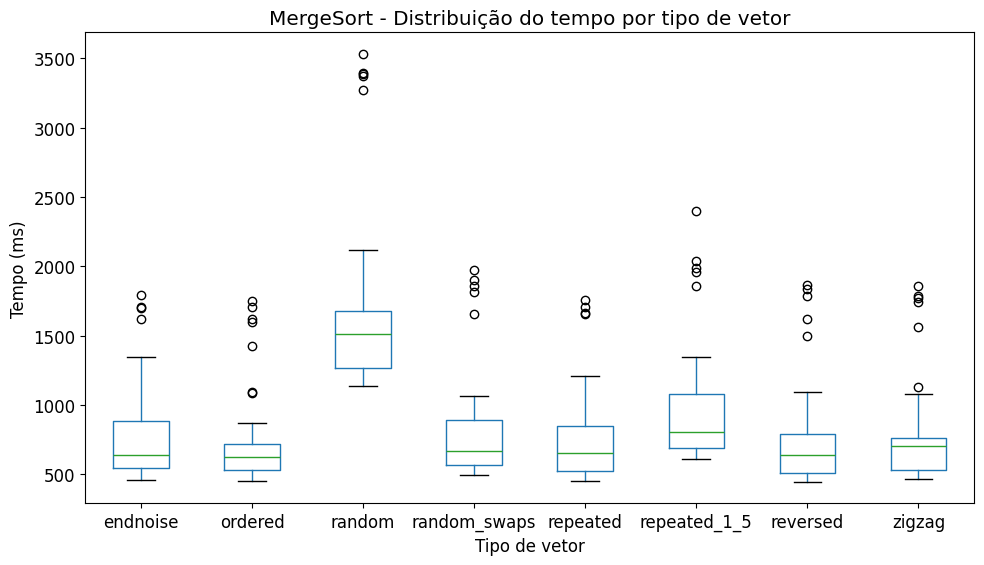

In [5]:
plt.figure(figsize=(8,5))
merge.boxplot(column="time_ms", by="vector_type", grid=False)

plt.title("MergeSort - Distribuição do tempo por tipo de vetor")
plt.suptitle("")
plt.ylabel("Tempo (ms)")
plt.xlabel("Tipo de vetor")

plt.tight_layout()
plt.show()

### Análise do gráfico:
Mergesort também é extremamente estável para os tipos de vetores, com maioria ficando na casa de 600 ms para resolução. Repeated de 1 a 5 apresenta tempos um poucos maiores em geral subindo para a casa de 750ms, indicando problemas leves do mergesort para lidar com este vetor. Random apresenta uma mediana com quase o tripo do valor das outras (1500 ms), indicando que o Mergesort tem muito problema em lidar com vetores randomizados.

## 5. Gráfico de tempo médio por estresse

<Figure size 1000x500 with 0 Axes>

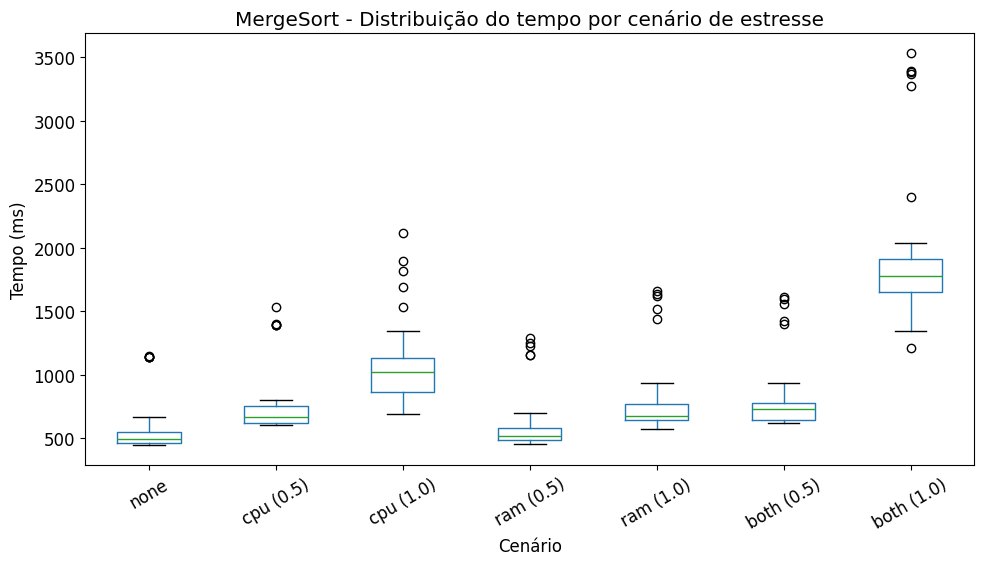

In [7]:
merge["cenario"] = merge.apply(
    lambda x: "none"
    if x["stress"] == "none"
    else f'{x["stress"]} ({x["carga"]})',
    axis=1
)

ordem = [
    "none",
    "cpu (0.5)",
    "cpu (1.0)",
    "ram (0.5)",
    "ram (1.0)",
    "both (0.5)",
    "both (1.0)"
]

merge["cenario"] = pd.Categorical(
    merge["cenario"],
    categories=ordem,
    ordered=True
)

plt.figure(figsize=(10,5))

merge.boxplot(
    column="time_ms",
    by="cenario",
    grid=False
)

plt.title("MergeSort - Distribuição do tempo por cenário de estresse")
plt.suptitle("")
plt.ylabel("Tempo (ms)")
plt.xlabel("Cenário")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Análise do gráfico:
CPU parece afetar muito mais que RAM, both é maior que ambos. Outliers correspondem aos casos random que demoram muito mais que o resto, exceto o outlier baixo em both.

## 6. Gráfico Estresse x Vetor

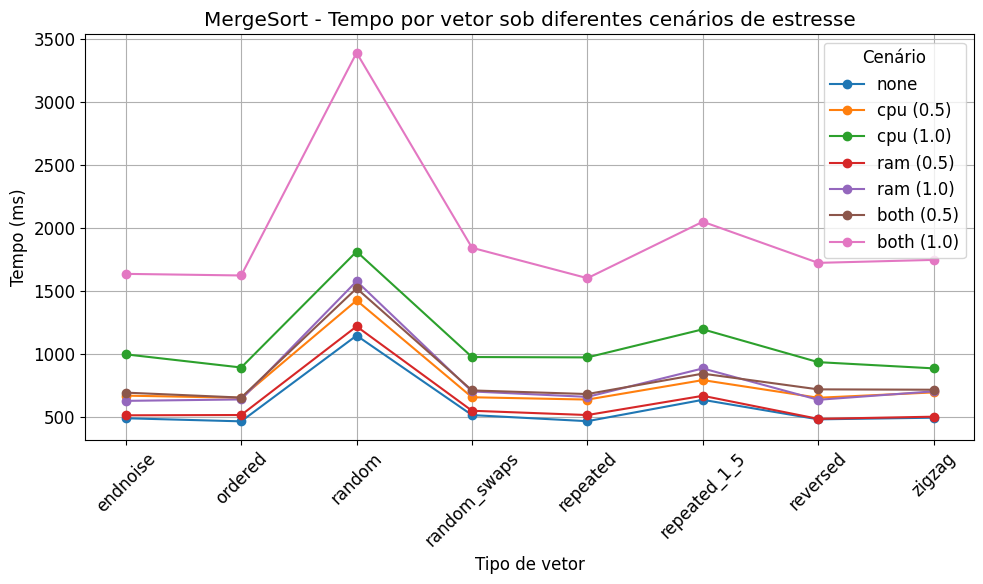

In [8]:
merge["cenario"] = merge.apply(
    lambda x: "none"
    if x["stress"] == "none"
    else f'{x["stress"]} ({x["carga"]})',
    axis=1
)

pivot = (
    merge
    .pivot_table(
        index="vector_type",
        columns="cenario",
        values="time_ms",
        aggfunc="mean"
    )
)

ordem = [
    "none",
    "cpu (0.5)",
    "cpu (1.0)",
    "ram (0.5)",
    "ram (1.0)",
    "both (0.5)",
    "both (1.0)"
]

pivot = pivot[ordem]

pivot.plot(marker="o", figsize=(10,6))

plt.ylabel("Tempo (ms)")
plt.xlabel("Tipo de vetor")
plt.title("MergeSort - Tempo por vetor sob diferentes cenários de estresse")

plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title="Cenário")

plt.tight_layout()
plt.show()

### Análise do gráfico:
RAM aumenta muito pouco tempo de execução com carga baixa e afeta o equivalente ao both com carga média quando com carga máxima.

CPU afeta muito mais que somente RAM, both com carga máxima degenera muito efetividade geral do algoritmo.

## 7. Heatmap

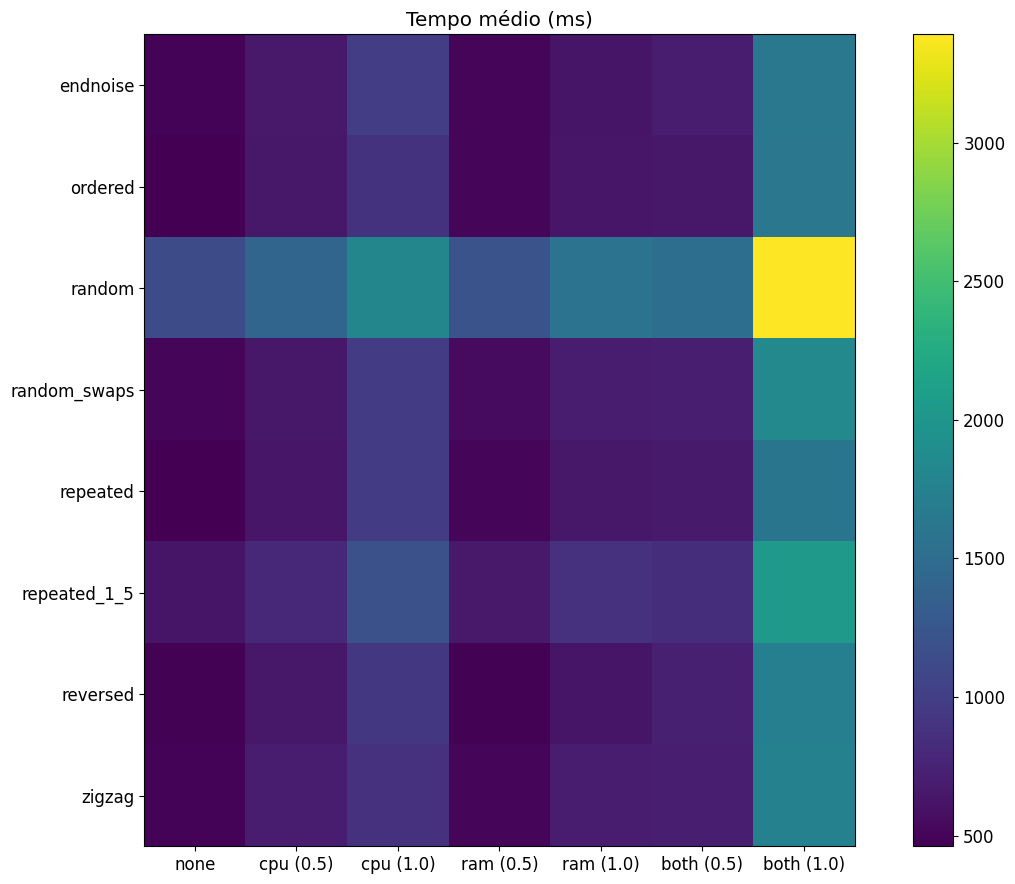

In [10]:
fig, ax = plt.subplots(figsize=(12,9))

im = ax.imshow(pivot.values)

ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)

ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(pivot.index)

plt.title("Tempo médio (ms)")

plt.colorbar(im)

plt.tight_layout()
plt.show()

## 8. Memória

<Figure size 800x500 with 0 Axes>

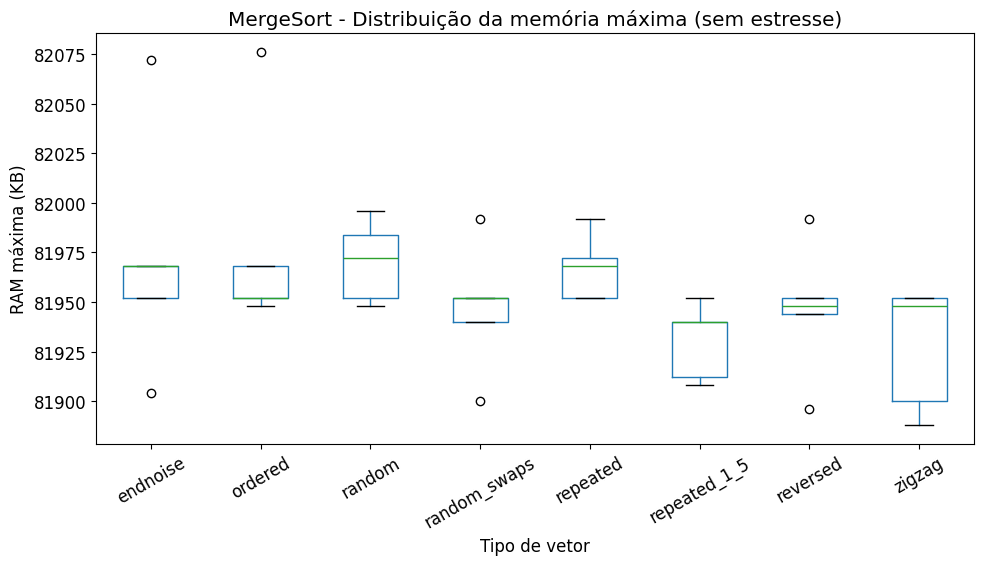

In [12]:
merge_none = merge[merge["stress"] == "none"]

plt.figure(figsize=(8,5))

merge_none.boxplot(
    column="ram_kb_max",
    by="vector_type",
    grid=False
)

plt.title("MergeSort - Distribuição da memória máxima (sem estresse)")
plt.suptitle("")
plt.ylabel("RAM máxima (KB)")
plt.xlabel("Tipo de vetor")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Uso bem maior do Mergesort comparado aos outros algoritmos de sorting, por volta de 82MB máximos utlizados por execução

<Figure size 800x500 with 0 Axes>

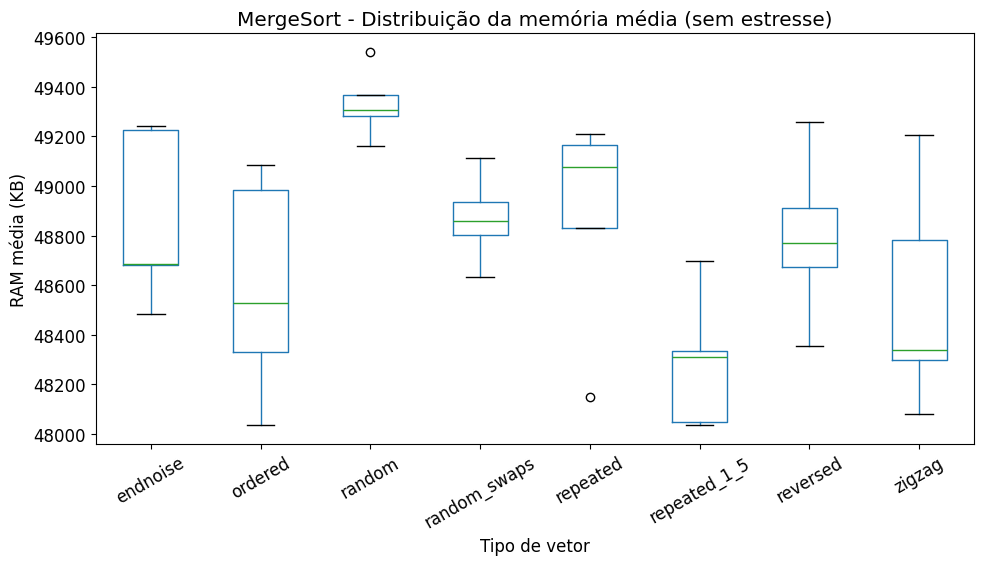

In [13]:
plt.figure(figsize=(8,5))

merge_none.boxplot(
    column="ram_kb_media",
    by="vector_type",
    grid=False
)

plt.title("MergeSort - Distribuição da memória média (sem estresse)")
plt.suptitle("")
plt.ylabel("RAM média (KB)")
plt.xlabel("Tipo de vetor")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

É possível ver que o uso médio de memória é bem mais baixo que o uso máximo, bem indicativo do funcionamento do mergesort. Uso médio mais distribuído ficando entre 48MB a 49,5MB, random consistentemente usa mais memória em média.

## 9. Energia

<Figure size 800x500 with 0 Axes>

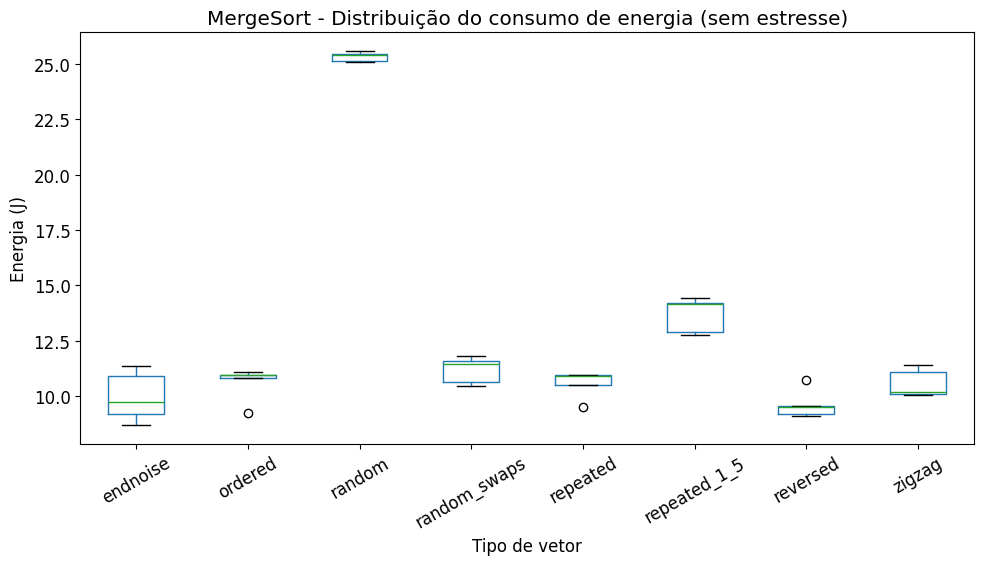

In [14]:
plt.figure(figsize=(8,5))

merge_none.boxplot(
    column="energy_j",
    by="vector_type",
    grid=False
)

plt.title("MergeSort - Distribuição do consumo de energia (sem estresse)")
plt.suptitle("")
plt.ylabel("Energia (J)")
plt.xlabel("Tipo de vetor")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Ainda possível ver extrema correlação entre tempo e energia por execução.

## 10 Correlações

In [16]:
merge_none[[
    "time_ms",
    "ram_kb_max",
    "ram_kb_media",
    "energy_j",
    "comparisons"
]].corr()

,time_ms,ram_kb_max,ram_kb_media,energy_j,comparisons
time_ms,1.000000,0.074182,0.404773,0.974686,0.682561
ram_kb_max,0.074182,1.000000,0.157838,0.120520,-0.199634
ram_kb_media,0.404773,0.157838,1.000000,0.403262,0.087425
energy_j,0.974686,0.120520,0.403262,1.000000,0.680225
comparisons,0.682561,-0.199634,0.087425,0.680225,1.000000


Tempo de execução e energia fortemente correlacionados. Tempo e comparação fortemente correlacionados.

Uso médio de memória pouco correlacionado com uso máximo, fortemente relacionado com tempo.

Comparações fracamente inversamente proporcionais ao uso máximo de memória.

Tudo isso indica que uso máximo de memória é estático e definido pelo tamanho do vetor enquanto uso médio de memória é muito mais indicativo do estado do processo

## 11. Conclusões automáticas

In [17]:
print("Maior tempo médio:")

print(
    merge.groupby("vector_type")["time_ms"]
    .mean()
    .idxmax()
)

print("Menor tempo médio:")

print(
    merge.groupby("vector_type")["time_ms"]
    .mean()
    .idxmin()
)

print("Estresse mais custoso:")

print(
    merge.groupby("stress")["time_ms"]
    .mean()
    .idxmax()
)

Maior tempo médio:
random
Menor tempo médio:
ordered
Estresse mais custoso:
both
